In [ ]:
# ===================================================================
# CELL 1: SETUP AND DEPENDENCIES
# Install required packages
# ===================================================================

# Install required packages for geospatial processing
!pip install rasterio geopandas tqdm -q

print("Setup complete!")

# ===================================================================
# CELL 2: IMPORT LIBRARIES
# Import all necessary libraries for inference
# ===================================================================

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
import geopandas as gpd
import tensorflow as tf
from tensorflow import keras
from tqdm import tqdm

# Check TensorFlow and GPU availability
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

In [ ]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.inference.data_utils import *
from src.inference.inference import full_inference_mbcnn, mtcnn_inference, save_and_clip_prediction_as_raster

In [ ]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.training.mbcnn import mbcnn

In [ ]:
# ===================================================================
# CELL 4: CONFIGURATION
# Set all parameters for your inference run
# ===================================================================

# Model configuration
N_CLASSES = 3          # Number of output classes (update based on your model)
BATCH_SIZE = 16        # Reduce if you encounter memory errors

BASE_PATH = "/content/drive/MyDrive/"

# File paths - UPDATE THESE TO YOUR ACTUAL PATHS
MODEL_PATH =  "/content/drive/MyDrive/Fine-Tuning-Workflow/checkpoint/checkpoint_partidos_amba_adapted/partidos_amba_best_precision.weights.h5"

# Input raster images (typically Sentinel-2 + additional data)
IMAGE_SOURCES = [
      "/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/s2_2025_partidos_ambas.tif",
      "/content/drive/MyDrive/Fine-Tuning-Workflow/Downloads/S2/s2_2025_building_density_updated.tif"  # Population Built-up Density or other auxiliary data
]

# Area of Interest boundary (GeoJSON format)
AOI_PATH = "/content/drive/MyDrive/Fine-Tuning-Workflow/Data/partidos_amba_IA_BID_2025.geojson"

# Output configuration
OUTPUT_DIR = BASE_PATH + "results_2025_partidos_amba_FT_best_precision/"
SAVE_PATH = OUTPUT_DIR + "prediction_map.tif"

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Print configuration summary
print("=== INFERENCE CONFIGURATION ===")
print(f"Classes: {N_CLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Model: {os.path.basename(MODEL_PATH)}")
print(f"Input images: {len(IMAGE_SOURCES)}")
print(f"Output: {os.path.basename(SAVE_PATH)}")
print("=" * 35)


=== INFERENCE CONFIGURATION ===
Classes: 3
Batch size: 16
Model: partidos_amba_best_precision.weights.h5
Input images: 2
Output: prediction_map.tif


In [ ]:
# ===================================================================
# CELL 5: FILE VALIDATION
# Check that all required files exist before proceeding
# ===================================================================

def validate_input_files():
    """Check if all required files exist and print their properties"""

    print("🔍 Validating input files...")
    all_valid = True

    # Check model file
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Model not found: {MODEL_PATH}")
        all_valid = False
    else:
        print(f"✅ Model found: {os.path.basename(MODEL_PATH)}")

    # Check input images
    for i, img_path in enumerate(IMAGE_SOURCES):
        if not os.path.exists(img_path):
            print(f"❌ Image {i+1} not found: {img_path}")
            all_valid = False
        else:
            # Get image properties
            with rio.open(img_path) as src:
                print(f"✅ Image {i+1}: {os.path.basename(img_path)}")
                print(f"   Size: {src.width} x {src.height} pixels")
                print(f"   Bands: {src.count}")
                print(f"   CRS: {src.crs}")

    # Check AOI file
    if not os.path.exists(AOI_PATH):
        print(f"❌ AOI not found: {AOI_PATH}")
        all_valid = False
    else:
        aoi = gpd.read_file(AOI_PATH)
        print(f"✅ AOI: {os.path.basename(AOI_PATH)}")
        print(f"   Features: {len(aoi)}")
        print(f"   CRS: {aoi.crs}")

    return all_valid

# Run validation
files_valid = validate_input_files()

if not files_valid:
    print("\n⚠️ Please fix file paths before proceeding!")

🔍 Validating input files...
✅ Model found: partidos_amba_best_precision.weights.h5
✅ Image 1: s2_2025_partidos_ambas.tif
   Size: 18590 x 17979 pixels
   Bands: 10
   CRS: EPSG:4326
✅ Image 2: s2_2025_building_density_updated.tif
   Size: 18590 x 17979 pixels
   Bands: 1
   CRS: EPSG:4326
✅ AOI: partidos_amba_IA_BID_2025.geojson
   Features: 1
   CRS: EPSG:4326


In [ ]:
# ===================================================================
# FIXED MODEL LOADING - HANDLE MULTIPLE OUTPUTS
# ===================================================================

def load_trained_model():
    """Reconstruct and load your trained MBCNN model"""

    print("Reconstructing MBCNN model architecture...")

    # Match your training configuration
    N_CLASSES = 3
    PATCH_SIZE = 128
    DROPOUT_RATE = 0.3

    # Input shapes matching your training
    input_shapes = {
        0: (PATCH_SIZE, PATCH_SIZE, 10),  # S2 input
        1: (PATCH_SIZE, PATCH_SIZE, 1)    # DEN input
    }

    # Recreate the exact same model architecture
    model = mbcnn(
        CL=N_CLASSES,
        input_shapes=input_shapes,
        dropout_rate=DROPOUT_RATE,
        batch_norm=True,
        drop_train=True
    )

    print("Model architecture created")
    print(f"Model parameters: {model.count_params():,}")

    # Load the trained weights
    weights_path = MODEL_PATH

    if os.path.exists(weights_path):
        model.load_weights(weights_path)
        print(f"Weights loaded from: {os.path.basename(weights_path)}")
    else:
        print(f"Weights file not found: {weights_path}")
        return None

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Model compiled and ready for inference")

    # Handle multiple outputs
    if isinstance(model.output, list):
        print(f"Model has {len(model.output)} outputs:")
        for i, output in enumerate(model.output):
            print(f"  Output {i}: {output.shape}")
    else:
        print(f"Model output shape: {model.output.shape}")

    return model

# Load your trained model
model = load_trained_model()

if model is not None:
    # Show input shapes
    print(f"\nModel Input Shapes:")
    for i, input_layer in enumerate(model.inputs):
        print(f"  Input {i}: {input_layer.shape}")

Reconstructing MBCNN model architecture...
Model architecture created
Model parameters: 125,507
Weights loaded from: partidos_amba_best_precision.weights.h5
Model compiled and ready for inference
Model has 1 outputs:
  Output 0: (None, 128, 128, 3)

Model Input Shapes:
  Input 0: (None, 128, 128, 10)
  Input 1: (None, 128, 128, 1)


In [ ]:
# ===================================================================
# UPDATED INFERENCE FUNCTION FOR MULTI-OUTPUT MODEL
# ===================================================================

def full_inference_mbcnn_multioutput(N_CLASSES, image_sources, model, save_path, aoi_path, batch_size=32):
    """
    Modified inference function to handle multi-output models
    """
    # Load and preprocess input rasters
    rasters = [rio.open(src).read().transpose(1, 2, 0) for src in image_sources]
    input1 = norm_s2(rasters[0])  # Normalize Sentinel-2 input
    input2 = rasters[1]           # Second input as is

    patch_height, patch_width = model.inputs[0].shape[1:3]
    stride = patch_height // 2
    image_height, image_width = input1.shape[:2]

    y_pred = np.zeros((image_height, image_width, N_CLASSES), dtype=np.float32)
    count_map = np.zeros((image_height, image_width, N_CLASSES), dtype=np.float32)

    dataset = PatchGenerator(input1, input2, patch_height, patch_width, stride, batch_size)
    window = hann_window(patch_height)[..., np.newaxis]

    pbar = tqdm(total=len(dataset), desc="Running Full Inference:")

    for batch in dataset:
        input_patches, batch_coords = batch

        batch_predictions = model.predict(input_patches, verbose=0)

        # Handle multiple outputs - use the main segmentation output
        if isinstance(batch_predictions, list):
            # Typically the first or last output is the main segmentation
            # You may need to adjust this index based on your model
            main_predictions = batch_predictions[0]  # or batch_predictions[-1]
            print(f"Using output 0 of {len(batch_predictions)} outputs for segmentation")
        else:
            main_predictions = batch_predictions

        for i in range(len(main_predictions)):
            y, x = batch_coords[i]
            patch_prediction = main_predictions[i] * window
            y_pred[y:y+patch_height, x:x+patch_width] += patch_prediction
            count_map[y:y+patch_height, x:x+patch_width] += window

        pbar.update(1)

    pbar.close()

    # Compute final classification map
    averaged_predictions = np.divide(y_pred, count_map, out=np.zeros_like(y_pred), where=(count_map != 0))
    final_pred = np.argmax(averaged_predictions, axis=-1) + 1

    # Save and clip the raster
    save_and_clip_prediction_as_raster(final_pred, image_sources[0], save_path, aoi_path)

print("Updated inference function loaded for multi-output models")

Updated inference function loaded for multi-output models


In [ ]:
# ===================================================================
# RUN SIMPLIFIED INFERENCE
# Since debug passed, let's run the actual inference
# ===================================================================

def run_full_inference():
    """Run the complete inference pipeline"""

    print("Starting full inference...")

    try:
        # Load and preprocess input rasters
        print("Loading rasters...")
        rasters = [rio.open(src).read().transpose(1, 2, 0) for src in IMAGE_SOURCES]
        input1 = norm_s2(rasters[0])
        input2 = rasters[1]

        # Get model parameters
        patch_height, patch_width = model.inputs[0].shape[1:3]
        stride = patch_height // 2
        image_height, image_width = input1.shape[:2]

        print(f"Processing {image_height}x{image_width} image with {patch_height}x{patch_width} patches")

        # Initialize prediction arrays
        y_pred = np.zeros((image_height, image_width, N_CLASSES), dtype=np.float32)
        count_map = np.zeros((image_height, image_width, N_CLASSES), dtype=np.float32)

        # Create patch generator
        dataset = PatchGenerator(input1, input2, patch_height, patch_width, stride, BATCH_SIZE)
        window = hann_window(patch_height)[..., np.newaxis]

        total_batches = len(dataset)
        print(f"Total batches to process: {total_batches}")

        # Process all patches
        pbar = tqdm(total=total_batches, desc="Processing patches")

        for batch_idx, batch in enumerate(dataset):
            input_patches, batch_coords = batch

            # Make prediction - your model returns single output, not list
            batch_predictions = model.predict(input_patches, verbose=0)

            # Accumulate predictions
            for i in range(len(batch_predictions)):
                y, x = batch_coords[i]
                patch_prediction = batch_predictions[i] * window
                y_pred[y:y+patch_height, x:x+patch_width] += patch_prediction
                count_map[y:y+patch_height, x:x+patch_width] += window

            pbar.update(1)

        pbar.close()

        # Compute final predictions
        print("Computing final classification map...")
        averaged_predictions = np.divide(y_pred, count_map, out=np.zeros_like(y_pred), where=(count_map != 0))
        final_pred = np.argmax(averaged_predictions, axis=-1) + 1

        print(f"Final prediction shape: {final_pred.shape}")
        print(f"Unique classes found: {np.unique(final_pred)}")

        # Save results
        print("Saving and clipping results...")
        save_and_clip_prediction_as_raster(final_pred, IMAGE_SOURCES[0], SAVE_PATH, AOI_PATH)

        print(f"Results saved to: {SAVE_PATH}")
        return True

    except Exception as e:
        print(f"Inference failed: {e}")
        import traceback
        traceback.print_exc()
        return False

# Run the full inference
success = run_full_inference()
print(f"\nInference completed successfully: {success}")

Starting full inference...
Loading rasters...
Processing 17979x18590 image with 128x128 patches
Total batches to process: 5040


Processing patches: 100%|██████████| 5040/5040 [09:26<00:00,  8.90it/s]


Computing final classification map...
Final prediction shape: (17979, 18590)
Unique classes found: [1 2 3]
Saving and clipping results...
Classified raster saved at: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map.tif
Results saved to: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map.tif

Inference completed successfully: True


📊 Loading and visualizing results...


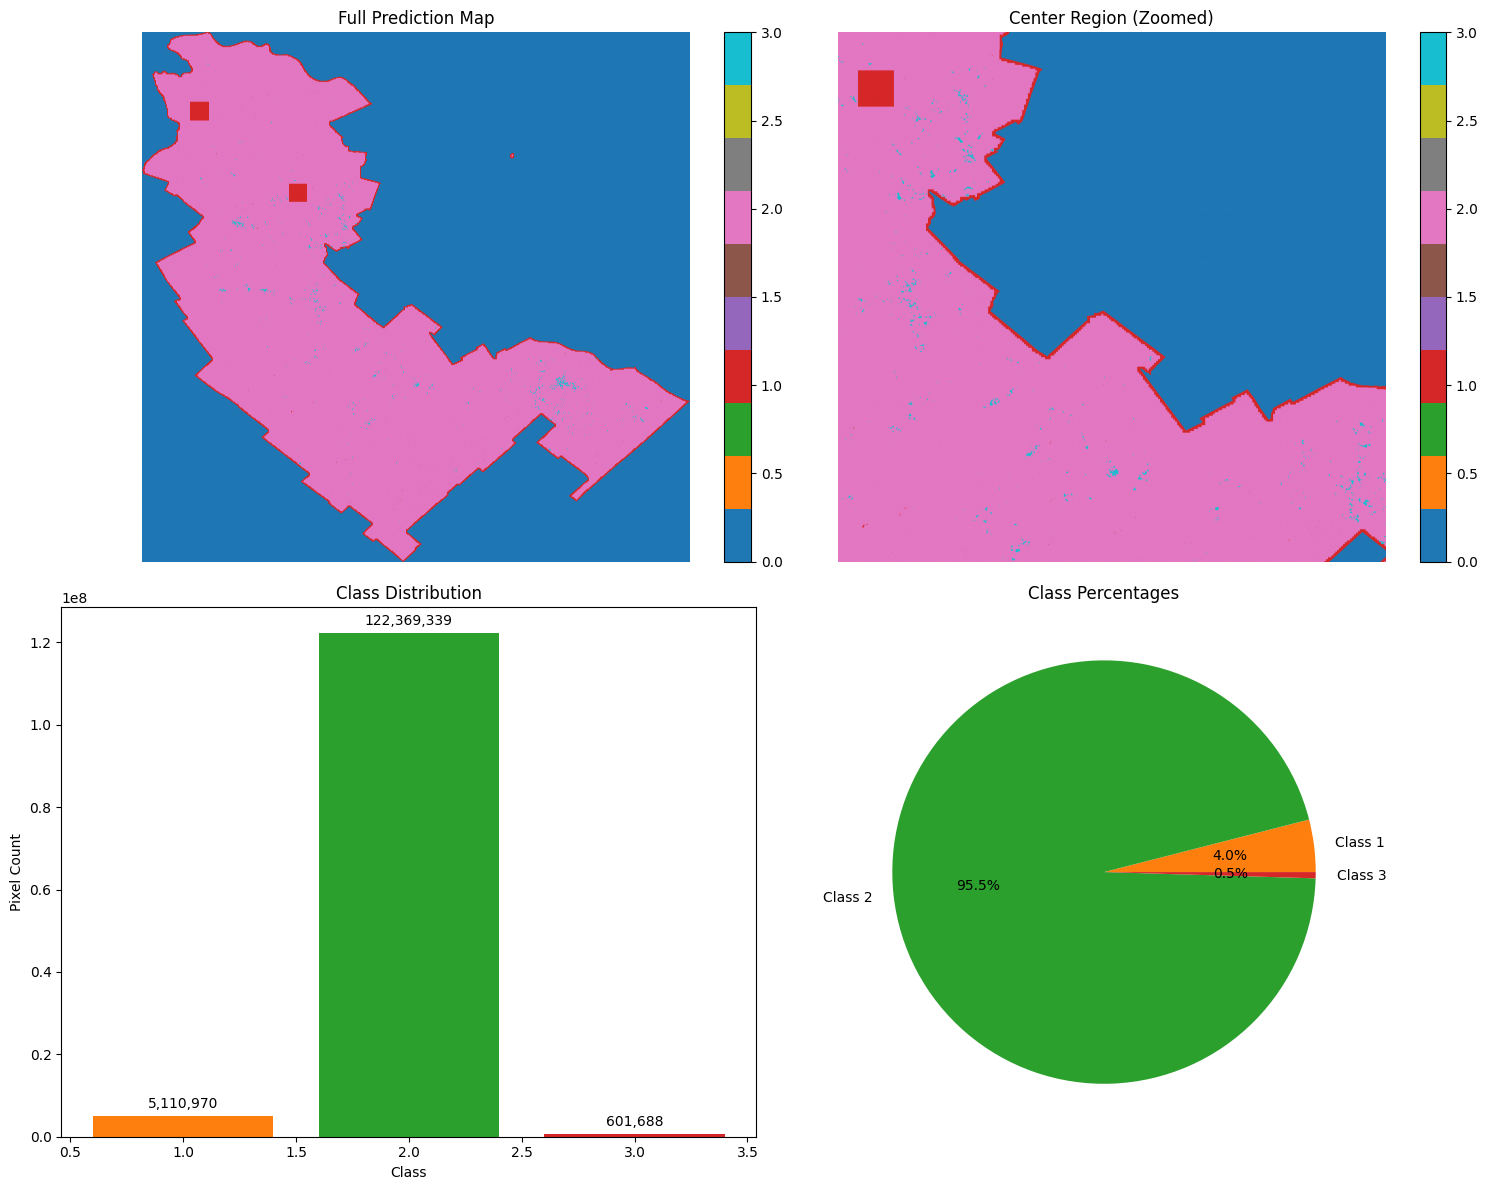


📈 Prediction Statistics:
  Image dimensions: (17979, 18590)
  Classes detected: [1 2 3]
  Total classified pixels: 128,081,997
  Output file size: 5.9 MB
  Coordinate system: EPSG:4326

📊 Per-class breakdown:
  Class 1: 5,110,970 pixels (4.0%)
  Class 2: 122,369,339 pixels (95.5%)
  Class 3: 601,688 pixels (0.5%)


In [ ]:

# ===================================================================
# CELL 10: VISUALIZE RESULTS
# Display and analyze the prediction results
# ===================================================================

def visualize_results():
    """Load and display the inference results"""

    if not success:
        print("⚠️ No results to visualize - inference did not complete successfully")
        return

    if not os.path.exists(SAVE_PATH):
        print(f"❌ Results file not found: {SAVE_PATH}")
        return

    print("📊 Loading and visualizing results...")

    # Load prediction map
    with rio.open(SAVE_PATH) as src:
        prediction = src.read(1)
        transform = src.transform
        crs = src.crs

    # Create visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Full prediction map
    im1 = ax1.imshow(prediction, cmap='tab10')
    ax1.set_title('Full Prediction Map')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046)

    # 2. Prediction map (zoomed to center)
    h, w = prediction.shape
    center_slice = prediction[h//4:3*h//4, w//4:3*w//4]
    im2 = ax2.imshow(center_slice, cmap='tab10')
    ax2.set_title('Center Region (Zoomed)')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046)

    # 3. Class distribution
    unique_classes, counts = np.unique(prediction[prediction > 0], return_counts=True)
    bars = ax3.bar(unique_classes, counts, color=plt.cm.tab10(unique_classes))
    ax3.set_title('Class Distribution')
    ax3.set_xlabel('Class')
    ax3.set_ylabel('Pixel Count')

    # Add count labels on bars
    for bar, count in zip(bars, counts):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
                f'{count:,}', ha='center', va='bottom')

    # 4. Class percentages
    percentages = counts / np.sum(counts) * 100
    ax4.pie(percentages, labels=[f'Class {c}' for c in unique_classes],
            autopct='%1.1f%%', colors=plt.cm.tab10(unique_classes))
    ax4.set_title('Class Percentages')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print("\n📈 Prediction Statistics:")
    print(f"  Image dimensions: {prediction.shape}")
    print(f"  Classes detected: {unique_classes}")
    print(f"  Total classified pixels: {np.sum(counts):,}")
    print(f"  Output file size: {os.path.getsize(SAVE_PATH) / (1024**2):.1f} MB")
    print(f"  Coordinate system: {crs}")

    # Per-class statistics
    print("\n📊 Per-class breakdown:")
    for cls, count, pct in zip(unique_classes, counts, percentages):
        print(f"  Class {cls}: {count:,} pixels ({pct:.1f}%)")

# Display results
visualize_results()


In [ ]:
# ===================================================================
# CELL 1: CREATE CLASS 3 RASTER OVERLAY
# Extract class 3 and prepare for web mapping
# ===================================================================

import rasterio as rio
import numpy as np
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import os

def create_class3_overlay(input_raster_path, output_rgba_path, target_class=3):
    """
    Create an RGBA raster where only class 3 is colored and rest is transparent
    """

    print(f"Creating class {target_class} overlay from: {input_raster_path}")

    with rio.open(input_raster_path) as src:
        # Read the classification data
        classification = src.read(1)
        profile = src.profile.copy()

        print(f"Input raster shape: {classification.shape}")
        print(f"Unique classes: {np.unique(classification)}")

        # Count class 3 pixels
        class3_pixels = np.sum(classification == target_class)
        total_pixels = classification.size
        percentage = (class3_pixels / total_pixels) * 100

        print(f"Class {target_class} pixels: {class3_pixels:,} ({percentage:.2f}% of total)")

        # Create RGBA array (Red, Green, Blue, Alpha)
        height, width = classification.shape
        rgba = np.zeros((4, height, width), dtype=np.uint8)

        # Create mask for class 3
        class3_mask = classification == target_class

        # Set color for class 3 pixels (bright red with transparency)
        rgba[0, class3_mask] = 255  # Red channel
        rgba[1, class3_mask] = 50   # Green channel (slight green for visibility)
        rgba[2, class3_mask] = 50   # Blue channel (slight blue for visibility)
        rgba[3, class3_mask] = 180  # Alpha channel (transparency: 180/255 ≈ 70% opaque)

        # All other pixels remain transparent (alpha = 0)

        # Update profile for RGBA output
        profile.update(
            count=4,
            dtype='uint8',
            compress='lzw',
            photometric='rgb'
        )

        # Save RGBA raster
        with rio.open(output_rgba_path, 'w', **profile) as dst:
            dst.write(rgba)

        print(f"RGBA overlay saved to: {output_rgba_path}")

        # Get bounds for map centering
        bounds = src.bounds
        center_lat = (bounds.bottom + bounds.top) / 2
        center_lon = (bounds.left + bounds.right) / 2

        return output_rgba_path, [center_lat, center_lon], bounds

def convert_to_web_mercator(input_path, output_path):
    """
    Convert raster to Web Mercator (EPSG:3857) for better web map performance
    """

    print("Converting to Web Mercator projection...")

    with rio.open(input_path) as src:
        # Calculate transform to Web Mercator
        dst_crs = CRS.from_epsg(3857)  # Web Mercator
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )

        # Update profile
        profile = src.profile.copy()
        profile.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Reproject
        with rio.open(output_path, 'w', **profile) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rio.band(src, i),
                    destination=rio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )

    print(f"Web Mercator version saved to: {output_path}")
    return output_path

# Create the class 3 overlay
RGBA_OUTPUT = SAVE_PATH.replace('.tif', '_class3_overlay.tif')
overlay_path, map_center, bounds = create_class3_overlay(
    input_raster_path=SAVE_PATH,
    output_rgba_path=RGBA_OUTPUT,
    target_class=3
)

# Optionally convert to Web Mercator for better performance
WEB_MERCATOR_OUTPUT = RGBA_OUTPUT.replace('.tif', '_webmercator.tif')
web_mercator_path = convert_to_web_mercator(RGBA_OUTPUT, WEB_MERCATOR_OUTPUT)

# ===================================================================
# CELL 2: CREATE LEAFLET MAP WITH RASTER OVERLAY
# Generate interactive map with satellite basemap and raster overlay
# ===================================================================

def create_raster_leaflet_map(overlay_raster_path, map_center, bounds, output_html_path):
    """
    Create Leaflet map with raster overlay using Georaster layer
    """

    # Calculate zoom level based on bounds
    lat_diff = abs(bounds.top - bounds.bottom)
    lon_diff = abs(bounds.right - bounds.left)

    # Rough zoom level calculation
    if max(lat_diff, lon_diff) > 1:
        zoom_level = 10
    elif max(lat_diff, lon_diff) > 0.1:
        zoom_level = 12
    else:
        zoom_level = 14

    html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Class 3 Detection - Raster Overlay</title>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <!-- Leaflet CSS -->
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />

    <!-- Georaster Layer CSS -->
    <script src="https://unpkg.com/georaster@1.6.0/dist/georaster.browser.bundle.min.js"></script>
    <script src="https://unpkg.com/georaster-layer-for-leaflet@3.10.0/dist/georaster-layer-for-leaflet.min.js"></script>

    <style>
        #map {{
            height: 100vh;
            width: 100%;
        }}

        .info {{
            padding: 10px 15px;
            font: 14px/16px Arial, Helvetica, sans-serif;
            background: white;
            background: rgba(255,255,255,0.9);
            box-shadow: 0 0 15px rgba(0,0,0,0.2);
            border-radius: 8px;
            position: absolute;
            top: 10px;
            right: 10px;
            z-index: 1000;
            max-width: 250px;
        }}

        .legend {{
            line-height: 20px;
            color: #555;
        }}

        .legend i {{
            width: 20px;
            height: 20px;
            float: left;
            margin-right: 8px;
            opacity: 0.8;
            border: 1px solid #ccc;
        }}

        .control-panel {{
            position: absolute;
            top: 10px;
            left: 60px;
            z-index: 1000;
            background: white;
            padding: 10px;
            border-radius: 5px;
            box-shadow: 0 0 10px rgba(0,0,0,0.3);
        }}

        .opacity-slider {{
            width: 150px;
        }}
    </style>
</head>
<body>
    <div id="map"></div>

    <!-- Info panel -->
    <div class="info">
        <h4>Class 3 Detection Results</h4>
        <div class="legend">
            <i style="background: rgba(255,50,50,0.7)"></i> Class 3 Areas<br>
        </div>
        <p><strong>Instructions:</strong><br>
        • Use layer control to switch basemaps<br>
        • Adjust overlay opacity with slider<br>
        • Zoom in for detail view</p>
    </div>

    <!-- Control panel for opacity -->
    <div class="control-panel">
        <label for="opacity">Overlay Opacity:</label><br>
        <input type="range" id="opacity" class="opacity-slider" min="0" max="1" step="0.1" value="0.7">
        <span id="opacity-value">70%</span>
    </div>

    <!-- Leaflet JavaScript -->
    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>

    <script>
        // Initialize map
        var map = L.map('map').setView([{map_center[0]}, {map_center[1]}], {zoom_level});

        // Basemap layers
        var satellite = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{
            attribution: 'Tiles © Esri — Source: Esri, Maxar, GeoEye, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community',
            maxZoom: 18
        }}).addTo(map);

        var osm = L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
            attribution: '© OpenStreetMap contributors',
            maxZoom: 18
        }});

        var cartoDB = L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
            attribution: '© OpenStreetMap © CartoDB',
            subdomains: 'abcd',
            maxZoom: 18
        }});

        // Basemap control
        var baseMaps = {{
            "Satellite": satellite,
            "OpenStreetMap": osm,
            "CartoDB Light": cartoDB
        }};

        // Note: For a complete implementation, you would need to:
        // 1. Convert the raster to tiles (using gdal2tiles or similar)
        // 2. Serve the tiles from a web server
        // 3. Add them as a tile layer

        // For now, we'll create a placeholder overlay
        var overlayBounds = [[{bounds.bottom}, {bounds.left}], [{bounds.top}, {bounds.right}]];

        // Placeholder for raster overlay (in real implementation, this would be tile layer)
        var rasterOverlay = L.rectangle(overlayBounds, {{
            color: 'red',
            weight: 2,
            opacity: 0.7,
            fillColor: 'red',
            fillOpacity: 0.3
        }});

        var overlayMaps = {{
            "Class 3 Detection": rasterOverlay
        }};

        // Add layer control
        L.control.layers(baseMaps, overlayMaps).addTo(map);

        // Add overlay to map
        rasterOverlay.addTo(map);

        // Fit map to bounds
        map.fitBounds(overlayBounds);

        // Opacity control
        var opacitySlider = document.getElementById('opacity');
        var opacityValue = document.getElementById('opacity-value');

        opacitySlider.addEventListener('input', function() {{
            var opacity = this.value;
            rasterOverlay.setStyle({{fillOpacity: opacity * 0.5, opacity: opacity}});
            opacityValue.textContent = Math.round(opacity * 100) + '%';
        }});

        // Add scale control
        L.control.scale().addTo(map);

        console.log('Map initialized. Bounds:', overlayBounds);

        // Add click event to show coordinates
        map.on('click', function(e) {{
            console.log('Clicked at:', e.latlng);
        }});
    </script>

    <div style="position: fixed; bottom: 10px; left: 10px; background: white; padding: 5px; border-radius: 3px; font-size: 12px;">
        <strong>Note:</strong> This is a preview. For full raster display, convert to tiles using gdal2tiles.
    </div>
</body>
</html>
"""

    # Save HTML file
    with open(output_html_path, 'w') as f:
        f.write(html_content)

    print(f"Leaflet map with raster overlay saved to: {output_html_path}")
    return output_html_path

# Create the Leaflet map
MAP_OUTPUT = SAVE_PATH.replace('.tif', '_class3_raster_map.html')

map_file = create_raster_leaflet_map(
    overlay_raster_path=RGBA_OUTPUT,
    map_center=map_center,
    bounds=bounds,
    output_html_path=MAP_OUTPUT
)

print(f"\nRaster overlay map created: {map_file}")

# ===================================================================
# CELL 3: CREATE TILES FOR PROPER RASTER DISPLAY (OPTIONAL)
# Convert raster to web tiles for smooth display
# ===================================================================

def create_web_tiles(input_raster_path, output_tiles_dir):
    """
    Create web tiles from the raster for proper Leaflet display
    This requires gdal2tiles.py to be available
    """

    import subprocess
    import shutil

    # Check if gdal2tiles is available
    try:
        result = subprocess.run(['gdal2tiles.py', '--help'], capture_output=True, text=True)
        if result.returncode != 0:
            print("gdal2tiles.py not found. Install GDAL or use alternative method.")
            return None
    except FileNotFoundError:
        print("gdal2tiles.py not found. Skipping tile generation.")
        return None

    print(f"Creating web tiles from: {input_raster_path}")

    # Create tiles directory
    os.makedirs(output_tiles_dir, exist_ok=True)

    # Run gdal2tiles
    cmd = [
        'gdal2tiles.py',
        '-p', 'mercator',           # Web Mercator projection
        '-z', '10-18',              # Zoom levels
        '-w', 'none',               # No world file
        '--s_srs=EPSG:4326',       # Source SRS
        input_raster_path,
        output_tiles_dir
    ]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, check=True)
        print(f"Tiles created successfully in: {output_tiles_dir}")
        return output_tiles_dir
    except subprocess.CalledProcessError as e:
        print(f"Error creating tiles: {e}")
        print("You can manually create tiles using QGIS or other tools")
        return None

# Optionally create tiles (uncomment if you have GDAL installed)
# TILES_DIR = SAVE_PATH.replace('.tif', '_tiles')
# tiles_path = create_web_tiles(RGBA_OUTPUT, TILES_DIR)

print("\nRaster overlay creation complete!")
print(f"RGBA overlay: {RGBA_OUTPUT}")
print(f"Leaflet map: {MAP_OUTPUT}")
print("\nFor full raster display in web maps, consider converting to tiles using gdal2tiles")

Creating class 3 overlay from: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map.tif
Input raster shape: (17979, 18590)
Unique classes: [0 1 2 3]
Class 3 pixels: 601,688 (0.18% of total)
RGBA overlay saved to: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_overlay.tif
Converting to Web Mercator projection...
Web Mercator version saved to: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_overlay_webmercator.tif
Leaflet map with raster overlay saved to: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_raster_map.html

Raster overlay map created: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_raster_map.html

Raster overlay creation complete!
RGBA overlay: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_overlay.tif
Leaflet map: /content/drive/MyDrive

In [ ]:
# ===================================================================
# COMPLETE WORKING CELL: CREATE INTERACTIVE LEAFLET MAP
# This cell converts Class 3 pixels to GeoJSON and creates a working map
# ===================================================================

import rasterio as rio
from rasterio import features
from shapely.geometry import shape
import geopandas as gpd
import json
import os

# ===================================================================
# STEP 1: CONVERT CLASS 3 RASTER TO GEOJSON
# ===================================================================

def raster_to_geojson(input_raster_path, output_geojson_path, target_class=3):
    """
    Convert class 3 pixels to GeoJSON polygons for Leaflet display
    """

    print(f"Converting class {target_class} pixels to GeoJSON polygons...")

    with rio.open(input_raster_path) as src:
        classification = src.read(1)
        transform = src.transform
        crs = src.crs

        print(f"  Input shape: {classification.shape}")
        print(f"  Input CRS: {crs}")

        # Create binary mask for target class
        mask = (classification == target_class).astype('uint8')
        class3_pixels = mask.sum()

        print(f"  Class {target_class} pixels: {class3_pixels:,}")

        if class3_pixels == 0:
            print("  ❌ No class 3 pixels found!")
            return None, None, None

        # Extract shapes (polygons) from raster
        print("  Extracting polygons from raster...")
        shapes_gen = features.shapes(mask, mask=mask, transform=transform)

        # Convert to geometries
        geometries = []
        for geom, value in shapes_gen:
            if value == 1:  # Only class 3 pixels
                geometries.append(shape(geom))

        print(f"  Extracted {len(geometries)} polygons")

        # Create GeoDataFrame
        gdf = gpd.GeoDataFrame(
            {'class': [target_class] * len(geometries)},
            geometry=geometries,
            crs=crs
        )

        # Simplify geometries to reduce file size (adjust tolerance as needed)
        print("  Simplifying geometries...")
        gdf['geometry'] = gdf.geometry.simplify(tolerance=5, preserve_topology=True)

        # Remove any empty geometries after simplification
        gdf = gdf[~gdf.geometry.is_empty]

        print(f"  Polygons after simplification: {len(gdf)}")

        # Reproject to WGS84 (EPSG:4326) - required for Leaflet
        print("  Reprojecting to WGS84...")
        gdf = gdf.to_crs(epsg=4326)

        # Save as GeoJSON
        gdf.to_file(output_geojson_path, driver='GeoJSON')

        file_size_mb = os.path.getsize(output_geojson_path) / (1024**2)
        print(f"  ✅ GeoJSON saved: {output_geojson_path}")
        print(f"  File size: {file_size_mb:.2f} MB")

        # Get bounds for map
        bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

        return output_geojson_path, center, bounds

# ===================================================================
# STEP 2: CREATE WORKING LEAFLET MAP
# ===================================================================

def create_working_leaflet_map(geojson_path, map_center, bounds, output_html_path):
    """
    Create a functional Leaflet map with GeoJSON overlay
    """

    print("Creating interactive Leaflet map...")

    # Read GeoJSON data
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)

    num_features = len(geojson_data['features'])
    print(f"  Loading {num_features} features into map")

    # Calculate appropriate zoom level
    lat_diff = abs(bounds[3] - bounds[1])
    lon_diff = abs(bounds[2] - bounds[0])

    if max(lat_diff, lon_diff) > 1:
        zoom_level = 10
    elif max(lat_diff, lon_diff) > 0.5:
        zoom_level = 11
    elif max(lat_diff, lon_diff) > 0.1:
        zoom_level = 12
    else:
        zoom_level = 14

    print(f"  Map center: [{map_center[0]:.4f}, {map_center[1]:.4f}]")
    print(f"  Zoom level: {zoom_level}")

    # Create HTML content with embedded GeoJSON
    html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Class 3 Detection - Interactive Map</title>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <style>
        body {{
            margin: 0;
            padding: 0;
            font-family: Arial, sans-serif;
        }}

        #map {{
            height: 100vh;
            width: 100%;
        }}

        .info {{
            padding: 12px 18px;
            background: rgba(255, 255, 255, 0.95);
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            border-radius: 8px;
            position: absolute;
            top: 10px;
            right: 10px;
            z-index: 1000;
            max-width: 280px;
        }}

        .info h4 {{
            margin: 0 0 10px 0;
            color: #333;
            font-size: 16px;
        }}

        .legend {{
            line-height: 24px;
            color: #555;
            font-size: 13px;
        }}

        .legend i {{
            width: 22px;
            height: 22px;
            float: left;
            margin-right: 10px;
            border: 1px solid rgba(0,0,0,0.2);
            border-radius: 3px;
        }}

        .stats {{
            margin-top: 12px;
            padding-top: 12px;
            border-top: 1px solid #ddd;
            font-size: 12px;
            color: #666;
        }}

        .opacity-control {{
            position: absolute;
            top: 10px;
            left: 60px;
            z-index: 1000;
            background: rgba(255, 255, 255, 0.95);
            padding: 12px 15px;
            border-radius: 8px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
        }}

        .opacity-slider {{
            width: 160px;
            margin-top: 5px;
        }}

        .leaflet-popup-content {{
            margin: 10px 12px;
            font-size: 13px;
        }}
    </style>
</head>
<body>
    <div id="map"></div>

    <!-- Info Panel -->
    <div class="info">
        <h4>🎯 Class 3 Detection Results</h4>
        <div class="legend">
            <i style="background: rgba(255, 50, 50, 0.7);"></i> Class 3 Areas
        </div>
        <div class="stats">
            <strong>Features:</strong> {num_features:,}<br>
            <strong>Area:</strong> <span id="total-area">Calculating...</span>
        </div>
        <p style="margin: 10px 0 0 0; font-size: 11px; color: #888;">
            💡 Click polygons for details<br>
            🗺️ Use layer control to switch basemaps
        </p>
    </div>

    <!-- Opacity Control -->
    <div class="opacity-control">
        <label for="opacity" style="font-size: 13px; font-weight: bold; color: #333;">
            Overlay Opacity
        </label><br>
        <input type="range" id="opacity" class="opacity-slider"
               min="0" max="1" step="0.05" value="0.65">
        <span id="opacity-value" style="font-size: 13px; margin-left: 8px; color: #555;">65%</span>
    </div>

    <!-- Leaflet JavaScript -->
    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <script>
        // Initialize map
        var map = L.map('map').setView([{map_center[0]}, {map_center[1]}], {zoom_level});

        // Basemap layers
        var satellite = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{
            attribution: '© Esri, Maxar, Earthstar Geographics',
            maxZoom: 18
        }}).addTo(map);

        var osm = L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
            attribution: '© OpenStreetMap contributors',
            maxZoom: 19
        }});

        var cartoDB = L.tileLayer('https://{{s}}.basemaps.cartocdn.com/light_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
            attribution: '© OpenStreetMap © CartoDB',
            subdomains: 'abcd',
            maxZoom: 19
        }});

        var cartoDBDark = L.tileLayer('https://{{s}}.basemaps.cartocdn.com/dark_all/{{z}}/{{x}}/{{y}}{{r}}.png', {{
            attribution: '© OpenStreetMap © CartoDB',
            subdomains: 'abcd',
            maxZoom: 19
        }});

        // GeoJSON data (embedded)
        var class3Data = {json.dumps(geojson_data)};

        // Style function for polygons
        function style(feature) {{
            return {{
                fillColor: '#ff3232',
                weight: 1.5,
                opacity: 0.8,
                color: '#cc0000',
                fillOpacity: 0.65
            }};
        }}

        // Highlight feature on hover
        function highlightFeature(e) {{
            var layer = e.target;
            layer.setStyle({{
                weight: 3,
                color: '#ffff00',
                fillOpacity: 0.85
            }});
            layer.bringToFront();
        }}

        function resetHighlight(e) {{
            class3Layer.resetStyle(e.target);
        }}

        // Click handler
        function onFeatureClick(e) {{
            var layer = e.target;
            var area = (turf.area(layer.toGeoJSON()) / 1000000).toFixed(4); // km²

            layer.bindPopup(`
                <strong>Class 3 Detection</strong><br>
                <strong>Area:</strong> ${{area}} km²<br>
                <strong>Coordinates:</strong><br>
                Lat: ${{e.latlng.lat.toFixed(5)}}<br>
                Lng: ${{e.latlng.lng.toFixed(5)}}
            `).openPopup();
        }}

        // Add GeoJSON layer with interactions
        var class3Layer = L.geoJSON(class3Data, {{
            style: style,
            onEachFeature: function(feature, layer) {{
                layer.on({{
                    mouseover: highlightFeature,
                    mouseout: resetHighlight,
                    click: onFeatureClick
                }});
            }}
        }}).addTo(map);

        // Layer control
        var baseMaps = {{
            "🛰️ Satellite": satellite,
            "🗺️ OpenStreetMap": osm,
            "🌍 CartoDB Light": cartoDB,
            "🌙 CartoDB Dark": cartoDBDark
        }};

        var overlayMaps = {{
            "Class 3 Areas": class3Layer
        }};

        L.control.layers(baseMaps, overlayMaps, {{position: 'topleft'}}).addTo(map);

        // Fit map to data bounds
        map.fitBounds(class3Layer.getBounds(), {{padding: [50, 50]}});

        // Opacity control
        var opacitySlider = document.getElementById('opacity');
        var opacityValue = document.getElementById('opacity-value');

        opacitySlider.addEventListener('input', function() {{
            var opacity = parseFloat(this.value);
            class3Layer.setStyle({{
                fillOpacity: opacity,
                opacity: Math.min(opacity + 0.2, 1)
            }});
            opacityValue.textContent = Math.round(opacity * 100) + '%';
        }});

        // Add scale control
        L.control.scale({{position: 'bottomleft'}}).addTo(map);

        // Calculate total area (requires turf.js)
        var script = document.createElement('script');
        script.src = 'https://cdn.jsdelivr.net/npm/@turf/turf@6/turf.min.js';
        script.onload = function() {{
            var totalArea = 0;
            class3Data.features.forEach(function(feature) {{
                totalArea += turf.area(feature);
            }});
            document.getElementById('total-area').textContent =
                (totalArea / 1000000).toFixed(2) + ' km²';
        }};
        document.head.appendChild(script);

        console.log('✅ Map loaded successfully');
        console.log('Features:', class3Data.features.length);
        console.log('Bounds:', class3Layer.getBounds());
    </script>
</body>
</html>
"""

    # Save HTML file
    with open(output_html_path, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"  ✅ Map saved to: {output_html_path}")
    print(f"  File size: {os.path.getsize(output_html_path) / 1024:.1f} KB")

    return output_html_path

# ===================================================================
# STEP 3: RUN THE COMPLETE WORKFLOW
# ===================================================================

print("=" * 60)
print("CREATING INTERACTIVE LEAFLET MAP")
print("=" * 60)

# Define output paths
GEOJSON_OUTPUT = SAVE_PATH.replace('.tif', '_class3.geojson')
MAP_OUTPUT = SAVE_PATH.replace('.tif', '_class3_interactive_map.html')

# Step 1: Convert raster to GeoJSON
geojson_path, map_center, bounds = raster_to_geojson(
    input_raster_path=SAVE_PATH,
    output_geojson_path=GEOJSON_OUTPUT,
    target_class=3
)

# Step 2: Create interactive map
if geojson_path is not None:
    map_file = create_working_leaflet_map(
        geojson_path=GEOJSON_OUTPUT,
        map_center=map_center,
        bounds=bounds,
        output_html_path=MAP_OUTPUT
    )

    print("\n" + "=" * 60)
    print("✅ SUCCESS!")
    print("=" * 60)
    print(f"📄 GeoJSON file: {GEOJSON_OUTPUT}")
    print(f"🗺️  Interactive map: {MAP_OUTPUT}")
    print("\n📥 Downloading map file...")

    # Download the HTML file
    from google.colab import files
    files.download(MAP_OUTPUT)

    print("\n💡 TIP: Open the downloaded HTML file in your browser to view the map!")

else:
    print("\n❌ Failed to create GeoJSON - no Class 3 pixels found in the prediction")

print("=" * 60)

CREATING INTERACTIVE LEAFLET MAP
Converting class 3 pixels to GeoJSON polygons...
  Input shape: (17979, 18590)
  Input CRS: EPSG:4326
  Class 3 pixels: 601,688
  Extracting polygons from raster...
  Extracted 2876 polygons
  Simplifying geometries...
  Polygons after simplification: 2876
  Reprojecting to WGS84...
  ✅ GeoJSON saved: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3.geojson
  File size: 0.93 MB
Creating interactive Leaflet map...
  Loading 2876 features into map
  Map center: [-34.5983, -58.5319]
  Zoom level: 10
  ✅ Map saved to: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_interactive_map.html
  File size: 881.4 KB

✅ SUCCESS!
📄 GeoJSON file: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3.geojson
🗺️  Interactive map: /content/drive/MyDrive/results_2025_partidos_amba_FT_best_precision/prediction_map_class3_interactive_map.html

📥 Downloading 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


💡 TIP: Open the downloaded HTML file in your browser to view the map!
